# Data Detective: Housing Data

A practical workflow for exploring, cleaning and preparing a dataset for machine learning.


## My goal

Use the local Day 2 housing dataset to find data-quality issues and create a clean, model-ready table.


## 1. imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("day_2/Slides-Notes/Datasets")
if not DATA_DIR.exists():
    DATA_DIR = Path("../Slides-Notes/Datasets")

OUTPUT_DIR = Path("day_2/Pracs/outputs")
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load and inspect the data


In [2]:
housing = pd.read_csv(DATA_DIR / "housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print(f"Rows: {housing.shape[0]:,} | Columns: {housing.shape[1]}")
housing.dtypes.to_frame("Data type")

Rows: 20,640 | Columns: 10


,Data type
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


### Numeric summary


In [4]:
housing.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


## 3. checking data quality


### Missing values


In [5]:
missing = housing.isna().sum()
missing[missing > 0].to_frame("Missing rows")

,Missing rows
total_bedrooms,207


Only `total_bedrooms` has missing values. I fill them with the median for the same ocean-proximity group, which is more specific than one overall median.


In [6]:
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(
    housing.groupby("ocean_proximity")["total_bedrooms"].transform("median")
)
print("Missing values left:", housing.isna().sum().sum())

Missing values left: 0


### checking for duplicate rows


In [7]:
duplicate_count = housing.duplicated().sum()
housing = housing.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {duplicate_count}")

Duplicates removed: 0


### detecting outliers with the IQR rule

Outliers are flagged for review instead of being deleted automatically.


In [8]:
q1, q3 = housing["median_house_value"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

housing["value_outlier"] = ~housing["median_house_value"].between(lower_limit, upper_limit)
print(f"Potential outliers: {housing['value_outlier'].sum():,}")
print(f"IQR limits: {lower_limit:,.0f} to {upper_limit:,.0f}")

Potential outliers: 1,071
IQR limits: -98,088 to 482,412


## 4. compare housing values

The sample size is shown because the groups are not equally large.


In [9]:
value_summary = (housing.groupby("ocean_proximity")["median_house_value"]
                 .agg(median_value="median", sample_size="size")
                 .sort_values("median_value")
                 .reset_index())
value_summary

,ocean_proximity,median_value,sample_size
0,INLAND,108500.0,6551
1,<1H OCEAN,214850.0,9136
2,NEAR OCEAN,229450.0,2658
3,NEAR BAY,233800.0,2290
4,ISLAND,414700.0,5


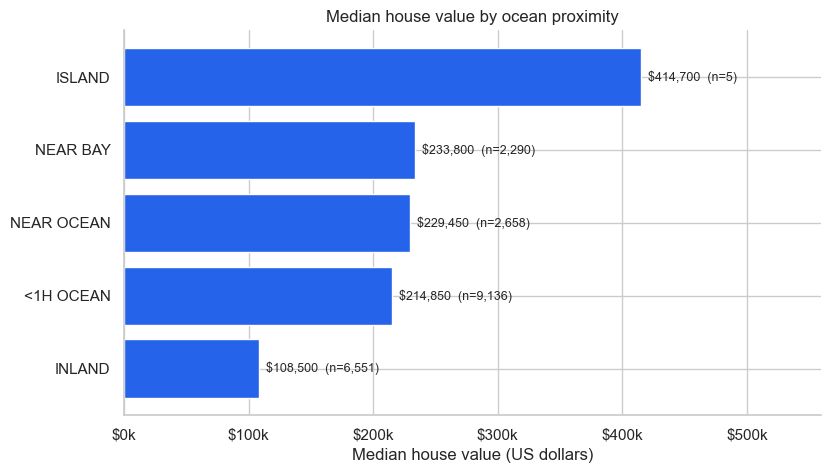

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(value_summary["ocean_proximity"], value_summary["median_value"], color="#2563EB")
labels = [f"${value:,.0f}  (n={size:,})" for value, size in zip(value_summary["median_value"], value_summary["sample_size"])]
ax.bar_label(bars, labels=labels, padding=5, fontsize=9)
ax.set(title="Median house value by ocean proximity", xlabel="Median house value (US dollars)", ylabel="")
ax.set_xlim(0, value_summary["median_value"].max() * 1.35)
ax.xaxis.set_major_formatter(lambda x, pos: f"${x/1000:.0f}k")
sns.despine()
plt.show()

## 5. creating useful features

Ratios make the raw totals easier to compare across areas of different sizes.


In [11]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_household"] = housing["population"] / housing["households"]

housing[["rooms_per_household", "bedrooms_per_room", "people_per_household"]].describe().round(2)

,rooms_per_household,bedrooms_per_room,people_per_household
count,20640.00,20640.00,20640.00
mean,5.43,0.21,3.07
std,2.47,0.07,10.39
min,0.85,0.04,0.69
25%,4.44,0.18,2.43
50%,5.23,0.20,2.82
75%,6.05,0.24,3.28
max,141.91,2.75,1243.33


## 6. encoding categories

One-hot encoding creates a separate 0/1 column for each location category.


In [12]:
model_data = pd.get_dummies(housing, columns=["ocean_proximity"], dtype=int)
model_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,value_outlier,rooms_per_household,bedrooms_per_room,people_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,6.984127,0.146591,2.555556,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,6.238137,0.155797,2.109842,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,8.288136,0.129516,2.802260,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,5.817352,0.184458,2.547945,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,6.281853,0.172096,2.181467,0,0,0,1,0


## 7. scaling the input features

The target and outlier flag are kept in their original form.


In [13]:
target = "median_house_value"
excluded = [target, "value_outlier"]
numeric_features = model_data.select_dtypes(include="number").columns.difference(excluded)

scaler = StandardScaler()
model_data[numeric_features] = scaler.fit_transform(model_data[numeric_features])
model_data[numeric_features].agg(["mean", "std"]).round(2)

,bedrooms_per_room,households,housing_median_age,latitude,longitude,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,people_per_household,population,rooms_per_household,total_bedrooms,total_rooms
mean,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 8. shuffling the rows

A fixed random state makes the result reproducible.


In [14]:
model_data = model_data.sample(frac=1, random_state=42).reset_index(drop=True)
model_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,value_outlier,rooms_per_household,bedrooms_per_room,people_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.279366,0.200449,-0.289187,-0.518327,-0.271477,-0.029562,-0.367597,-1.152489,47700.0,False,-0.499896,1.034176,0.077681,-0.891156,1.466514,-0.015566,-0.353264,-0.384466
1,0.054757,-0.230283,0.108104,0.140833,-0.271477,0.123206,0.220915,-0.705015,45800.0,False,-0.157477,-1.077102,-0.037634,-0.891156,1.466514,-0.015566,-0.353264,-0.384466
2,-1.432653,1.015093,1.856182,0.547423,-0.271477,-0.101972,1.212230,-0.205588,500001.0,True,-0.586814,-1.588841,-0.164679,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
3,0.424114,-0.632923,-0.924851,0.190339,-0.235710,0.246834,-0.011874,0.982710,218600.0,False,0.296929,-1.079737,0.035990,1.122138,-0.681889,-0.015566,-0.353264,-0.384466
4,-1.178096,0.462633,0.425936,-0.130532,-0.173714,-0.320086,-0.187120,-0.076678,278000.0,False,0.025864,-0.252591,-0.056520,-0.891156,-0.681889,-0.015566,-0.353264,2.601007


## 9. my correlation heatmap

This focuses on the original numeric columns and the three new ratio features.


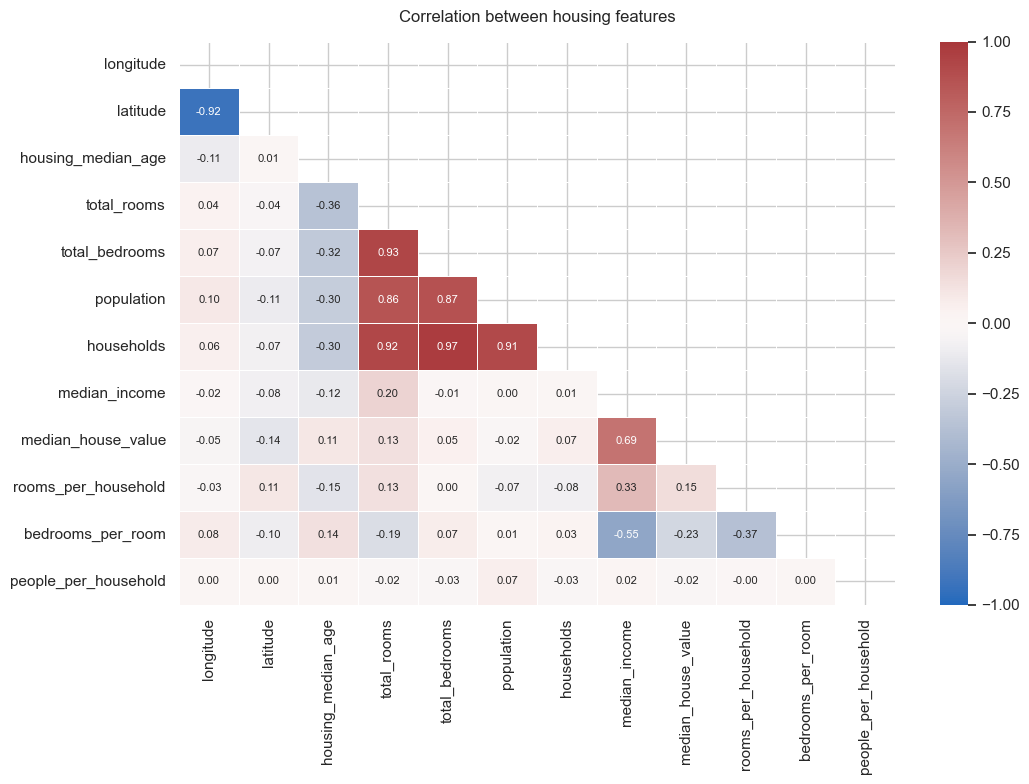

In [15]:
correlation_columns = ["longitude", "latitude", "housing_median_age", "total_rooms",
                       "total_bedrooms", "population", "households", "median_income",
                       "median_house_value", "rooms_per_household",
                       "bedrooms_per_room", "people_per_household"]
correlation = housing[correlation_columns].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlation, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5, ax=ax)
ax.set_title("Correlation between housing features", pad=14)
plt.tight_layout()
plt.show()

## 10. saving the cleaned dataset


In [16]:
output_path = OUTPUT_DIR / "housing_cleaned.csv"
model_data.to_csv(output_path, index=False)
print(f"Saved {len(model_data):,} rows to {output_path.resolve()}")

Saved 20,640 rows to D:\development\sdc_traing_2026\day_2\Pracs\outputs\housing_cleaned.csv


## my lessons learned

- The missing bedroom values were filled using their local category median.
- Extreme house values were flagged rather than removed without investigation.
- Categorical data was one-hot encoded and model inputs were standardised.
- The final shuffled dataset is ready for a later machine-learning practical.
